In [2]:
# Importing necessary libraries 
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
seed = 1234
np.random.seed(seed)
tf.random.set_seed(seed)


In [3]:
#  Extracting from dataset the features and Target variable
california_housing = fetch_california_housing()
feature = pd.DataFrame(data = california_housing.data, columns = california_housing.feature_names)
Target = pd.DataFrame(data = california_housing.target, columns = california_housing.target_names)
print(f"The features dataset : \n {feature.head(5)}")
print(f"The target dataset :\n {Target.head(5)}")

The features dataset : 
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
The target dataset :
    MedHouseVal
0        4.526
1        3.585
2        3.521
3        3.413
4        3.422


In [4]:
# dividing the dataset into training , testing and validation sets
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test  = train_test_split(feature,Target, test_size = 0.1, random_state= seed)

# checking the shape of the training, testing and validation sets
print(f"The shape of training : \n x_train {x_train.shape},\n y_train {y_train.shape}")


The shape of training : 
 x_train (18576, 8),
 y_train (18576, 1)


In [7]:
# Scaling the spilt dataset with StandardScaler 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print(f"The scaled training dataset :\n {x_train[:5]}\n")
print(f"The scaled testing dataset :  \n {x_test[:5]}")

The scaled training dataset :
 [[-0.61905459  1.4604044  -0.76857114 -0.22686957 -0.1071632   0.11250319
  -0.75552235  0.70400575]
 [-0.10191344  0.42563491 -0.20675139  0.01770588  0.47070303 -0.0091239
   0.92280917 -1.37078179]
 [-0.89120097  0.42563491 -0.35724616  0.02990297  1.50821552 -0.01067446
  -0.9477335   2.48882299]
 [-0.52089913  0.74402552 -0.12615965 -0.30310115 -0.13451259 -0.03667326
   0.86186417 -0.78584169]
 [ 0.34663968 -0.21114632 -0.24984837 -0.28034818 -0.41506444 -0.09076732
   0.99313032 -1.44577411]]

The scaled testing dataset :  
 [[-1.01860922e-01  1.85839267e+00 -2.33541216e-01 -3.94978242e-02
  -7.15025533e-01 -1.24369113e-01  1.01188263e+00 -1.43577514e+00]
 [ 8.80849064e-01  1.85839267e+00  2.72181339e-01 -1.14359898e-01
   3.68363360e-01 -1.03850066e-02 -6.99265429e-01  6.84007801e-01]
 [-8.17449880e-05  1.22161144e+00 -2.76602582e-01 -1.49828468e-01
  -7.61784175e-01 -1.24722174e-01  1.00719455e+00 -1.43577514e+00]
 [-2.12463061e-01 -6.88732235e-0

In [ ]:
# neural network model building using keras API
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation= 'relu', input_shape = (8,), name = "input_layer"),
    tf.keras.layers.Dense(32, activation = 'relu', name = "hidden_layer_1"),
    tf.keras.layers.Dense(1, name = "output_layer")
])

c:\Users\tamrat.worku\.conda\envs\mysql_packages\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compile the model for training configure 
model.compile(
    optimizer = "sgd",
    loss = "mse",
    metrics = ["accuracy"],
)


In [ ]:
# Train the model
history = model.fit(
    x_train,
    y_train,
    batch_size = 32,
    epochs = 10,
    verbose = 1,
    validation_split = 0.1
   )



Epoch 1/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0033 - loss: 0.3440 - val_accuracy: 0.0011 - val_loss: 0.3361
Epoch 2/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0033 - loss: 0.3391 - val_accuracy: 0.0011 - val_loss: 0.3321
Epoch 3/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0033 - loss: 0.3349 - val_accuracy: 0.0011 - val_loss: 0.3281
Epoch 4/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0033 - loss: 0.3309 - val_accuracy: 0.0011 - val_loss: 0.3241
Epoch 5/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0033 - loss: 0.3271 - val_accuracy: 0.0011 - val_loss: 0.3214
Epoch 6/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0033 - loss: 0.3237 - val_accuracy: 0.0011 - val_loss: 0.3183
Epoch 7/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0033 - loss: 0.3205 - val_accuracy: 0.0011 - val_loss: 0.3161
Epoch 8/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0033 - loss: 0.3173 - val_accuracy: 0.

In [ ]:
# Evaluate  the model
loss, accuracy = model.evaluate(
    x_test,
    y_test,
    verbose =False
)

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


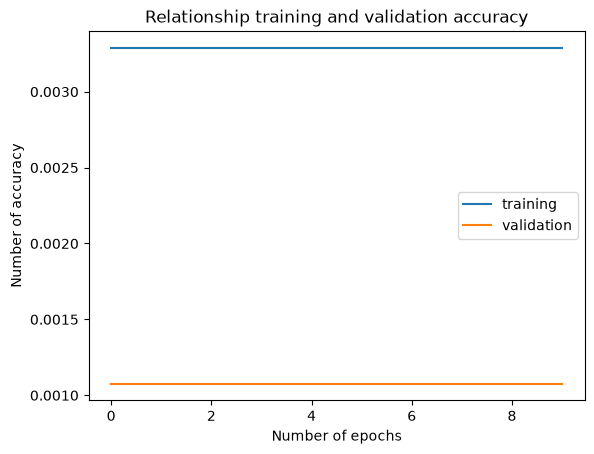

The training loss, 0.3179


In [ ]:
# visualized the training and validation accuracy and training loss value 
plt.Figure(figsize= (12,6))
print(history.history.keys())

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.xlabel("Number of epochs")
plt.ylabel("Number of accuracy")
plt.title("Relationship training and validation accuracy")
plt.legend(["training", "validation"])
plt.show()

print(f"The training loss, {loss:.4}")

In [ ]:
import sys
print(sys.executable)

c:\Users\tamrat.worku\.conda\envs\mysql_packages\python.exe
